In [1]:
!pip install -q --upgrade wandb

In [2]:
!pip install -q torchinfo

In [3]:
import os #работа с путями и папками датасета
import random #фиксация случайности для воспроизводимости

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm #строка прогресса во время обучения

import torch #основная библиотека PyTorch
import torch.nn as nn # слои нейросети, функция потерь, классы моделей
import torch.nn.functional as F #функции активации, например ReLU
import torch.optim as optim #оптимизаторы, например Adam

from torch.utils.data import DataLoader #формирование батчей и передача изображений модели
from torchvision import datasets #загрузка изображений из папок через ImageFolder
import torchvision.transforms as transforms #изменение размера, преобразование в тензор и нормализация изображений

from torchinfo import summary #вывод структуры модели и количества параметров

import wandb #логирование параметров, loss, метрик и моделей. Он нужен уже с baseline, потому что по критериям должны логироваться все эксперименты

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
DATA_DIR = '/content/drive/MyDrive/СМАДИМО/ГП5/the_wildfire_dataset_2n_version'

# Названия выборок и классов будем использовать во всём ноутбуке
splits = ['train', 'val', 'test']
classes = ['fire', 'nofire']

In [23]:
# Проверяем, что основная папка датасета существует
assert os.path.exists(DATA_DIR), f'Папка не найдена: {DATA_DIR}'

# Проверяем структуру каждой выборки
for split in splits:
    split_path = os.path.join(DATA_DIR, split)

    assert os.path.exists(split_path), f'Не найдена выборка: {split}'
    print(f'{split}: {os.listdir(split_path)}')

train: ['fire', 'nofire']
val: ['fire', 'nofire']
test: ['fire', 'nofire']


## EDA:

Посчитаем количество изображений классов `fire` и `nofire` в каждой выборке. Это позволит определить, есть ли дисбаланс, который необходимо учитывать при обучении и оценке моделей

Проверим баланс классов:


In [24]:
# Расширения файлов, которые встречаются в датасете
image_extensions = ('.jpg', '.jpeg', '.png')

class_counts = {}

for split in splits:
    class_counts[split] = {}

    print(f'\n{split.upper()}')

    for class_name in classes:
        class_path = os.path.join(DATA_DIR, split, class_name)

        # Оставляем только файлы изображений
        image_files = [
            file_name
            for file_name in os.listdir(class_path)
            if file_name.lower().endswith(image_extensions)
        ]

        class_counts[split][class_name] = len(image_files)
        print(f'{class_name}: {len(image_files)}')

    # Считаем общее количество изображений и долю каждого класса
    total = sum(class_counts[split].values())
    print(f'Всего: {total}')

    for class_name in classes:
        class_share = class_counts[split][class_name] / total
        print(f'Доля {class_name}: {class_share:.2%}')


TRAIN
fire: 730
nofire: 1157
Всего: 1887
Доля fire: 38.69%
Доля nofire: 61.31%

VAL
fire: 156
nofire: 246
Всего: 402
Доля fire: 38.81%
Доля nofire: 61.19%

TEST
fire: 159
nofire: 251
Всего: 410
Доля fire: 38.78%
Доля nofire: 61.22%


Проверим размеры, форматы и цветовые режимы изображений, а также убедимся, что в датасете нет повреждённых файлов. Эта информация нужна для выбора единого способа предобработки перед обучением моделей:

In [25]:
from collections import Counter
from PIL import Image

image_sizes = Counter()
image_formats = Counter()
image_modes = Counter()

# Список файлов, которые не удалось открыть
broken_files = []

for split in splits:
    for class_name in classes:
        class_path = os.path.join(DATA_DIR, split, class_name)

        image_files = [
            file_name
            for file_name in os.listdir(class_path)
            if file_name.lower().endswith(image_extensions)
        ]

        for file_name in tqdm(image_files, desc=f'{split}/{class_name}'):
            image_path = os.path.join(class_path, file_name)

            try:
                with Image.open(image_path) as image:
                    image_sizes[image.size] += 1
                    image_formats[image.format] += 1
                    image_modes[image.mode] += 1

                    # Проверяем, что файл изображения читается корректно
                    image.verify()

            except Exception as error:
                broken_files.append((image_path, str(error)))

print('\nСамые частые размеры изображений:')
for size, count in image_sizes.most_common(10):
    print(f'{size}: {count}')

print('\nФорматы изображений:')
for image_format, count in image_formats.items():
    print(f'{image_format}: {count}')

print('\nЦветовые режимы:')
for mode, count in image_modes.items():
    print(f'{mode}: {count}')

print('\nПовреждённых файлов:', len(broken_files))

if broken_files:
    print('\nПервые найденные ошибки:')
    for file_path, error in broken_files[:5]:
        print(f'{file_path}: {error}')

train/nofire:  87%|████████▋ | 1010/1157 [00:08<00:00, 260.77it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
test/nofire:   0%|          | 0/251 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
test/nofire:   2%|▏         | 4/251 [00:00<00:41,  6.01it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
t


Самые частые размеры изображений:
(6000, 4000): 119
(4032, 3024): 102
(5472, 3648): 87
(3992, 2992): 59
(4000, 3000): 54
(4000, 2250): 50
(5464, 3640): 42
(3264, 2448): 38
(5184, 3456): 37
(4000, 6000): 37

Форматы изображений:
JPEG: 2640
MPO: 41
PNG: 18

Цветовые режимы:
RGB: 2687
RGBA: 12

Повреждённых файлов: 0


Повреждённых изображений в датасете не обнаружено. Большинство файлов имеют формат JPEG и цветовой режим RGB, но также встречаются PNG, MPO и изображения с режимом RGBA. Размеры изображений значительно различаются, поэтому перед обучением потребуется привести их к единому размеру и цветовому режиму RGB.

Посмотрим случайные изображения классов:

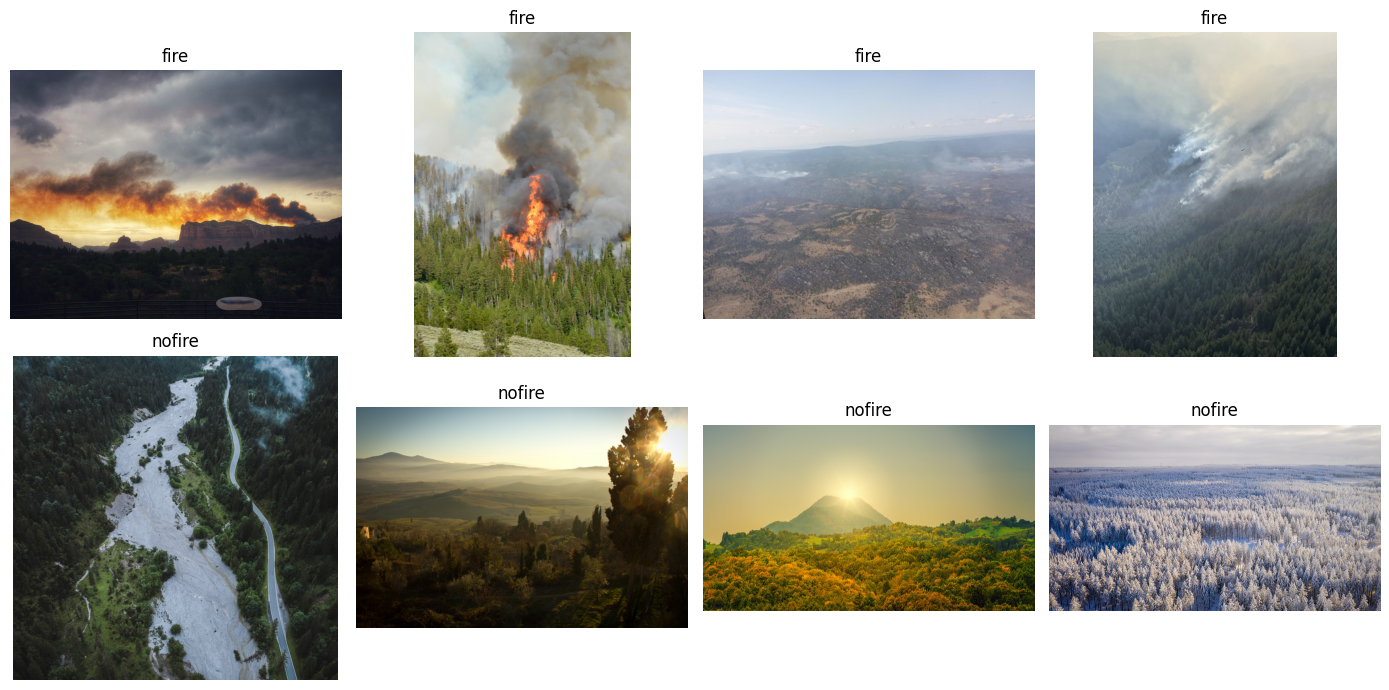

In [26]:
# Выводим по четыре случайных изображения каждого класса из train-выборки
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, class_name in enumerate(classes):
    class_path = os.path.join(DATA_DIR, 'train', class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    ]

    selected_files = random.sample(image_files, 4)

    for col, file_name in enumerate(selected_files):
        image_path = os.path.join(class_path, file_name)

        with Image.open(image_path) as image:
            image = image.convert('RGB')

            axes[row, col].imshow(image)
            axes[row, col].set_title(class_name)
            axes[row, col].axis('off')

plt.tight_layout()
plt.show()

Проверим, не встречаются ли дубликаты одновременно в `train`, `val` и `test`. Наличие таких файлов привело бы к утечке данных и завышенной оценке качества модели:

In [27]:
import hashlib

# Вычисляем MD5-хеш файла, чтобы сравнивать изображения по содержимому
def get_file_hash(file_path):
    file_hash = hashlib.md5()

    # Читаем файл частями, чтобы не загружать большое изображение целиком в память
    with open(file_path, 'rb') as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b''):
            file_hash.update(chunk)

    return file_hash.hexdigest()


# Собираем уникальные хеши изображений для каждой выборки
split_hashes = {}

for split in splits:
    split_hashes[split] = set()

    for class_name in classes:
        class_path = os.path.join(DATA_DIR, split, class_name)

        image_files = [
            file_name
            for file_name in os.listdir(class_path)
            if file_name.lower().endswith(image_extensions)
        ]

        for file_name in tqdm(image_files, desc=f'{split}/{class_name}'):
            image_path = os.path.join(class_path, file_name)
            split_hashes[split].add(get_file_hash(image_path))

# Проверяем пересечения между выборками
print('Совпадения train и val:', len(split_hashes['train'] & split_hashes['val']))
print('Совпадения train и test:', len(split_hashes['train'] & split_hashes['test']))
print('Совпадения val и test:', len(split_hashes['val'] & split_hashes['test']))

test/nofire: 100%|██████████| 251/251 [00:07<00:00, 34.06it/s]

Совпадения train и val: 0
Совпадения train и test: 0
Совпадения val и test: 0


Полных дубликатов между обучающей, валидационной и тестовой выборками не обнаружено. Явной утечки данных через одинаковые файлы нет

## Подготовка данных:

Перед обучением приведём все изображения к единому размеру `224 × 224` и цветовому режиму RGB. Уменьшенную копию сохраним отдельно, чтобы не изменять исходный датасет и ускорить загрузку изображений во время обучения.

In [15]:
from PIL import ImageOps

# Папка для подготовленной копии датасета и единый размер изображений
resized_data_dir = DATA_DIR + '_224'
target_size = (224, 224)

for split in splits:
    for class_name in classes:
        source_dir = os.path.join(DATA_DIR, split, class_name)
        target_dir = os.path.join(resized_data_dir, split, class_name)

        os.makedirs(target_dir, exist_ok=True)

        image_files = [
            file_name
            for file_name in os.listdir(source_dir)
            if file_name.lower().endswith(image_extensions)
        ]

        for file_name in tqdm(image_files, desc=f'{split}/{class_name}'):
            source_path = os.path.join(source_dir, file_name)

            # Все подготовленные изображения сохраняем в формате JPEG
            target_name = os.path.splitext(file_name)[0] + '.jpg'
            target_path = os.path.join(target_dir, target_name)

            # Не обрабатываем изображение повторно при перезапуске ячейки
            if os.path.exists(target_path):
                continue

            with Image.open(source_path) as image:
                image = ImageOps.exif_transpose(image)
                image = image.convert('RGB')

                # Приводим изображение к единому размеру без чёрных полей
                image = image.resize(target_size, Image.Resampling.LANCZOS)

                image.save(target_path, format='JPEG', quality=90)

print('Подготовленный датасет сохранён:', resized_data_dir)

test/nofire: 100%|██████████| 251/251 [02:31<00:00,  1.66it/s]

Уменьшенный датасет создан: /content/drive/MyDrive/СМАДИМО/ГП5/the_wildfire_dataset_2n_version_224


Проверим, что количество изображений не изменилось после обработки, а все файлы имеют размер `224 × 224` и цветовой режим RGB.

In [33]:
for split in splits:
    print(f'\n{split.upper()}')

    for class_name in classes:
        class_path = os.path.join(resized_data_dir, split, class_name)

        # После обработки все изображения сохранены в формате JPEG
        image_files = [
            file_name
            for file_name in os.listdir(class_path)
            if file_name.lower().endswith(('.jpg', '.jpeg'))
        ]

        image_sizes = set()
        image_modes = set()

        # Проверяем характеристики всех изображений в папке
        for file_name in image_files:
            image_path = os.path.join(class_path, file_name)

            with Image.open(image_path) as image:
                image_sizes.add(image.size)
                image_modes.add(image.mode)

        # Проверяем, что количество файлов совпадает с исходным датасетом
        assert len(image_files) == class_counts[split][class_name]

        # Проверяем единый размер и цветовой режим
        assert image_sizes == {target_size}
        assert image_modes == {'RGB'}

        print(
            f'{class_name}: {len(image_files)} файлов, '
            f'размер={image_sizes}, режим={image_modes}'
        )


TRAIN
fire: 730 файлов, размер={(224, 224)}, режим={'RGB'}
nofire: 1157 файлов, размер={(224, 224)}, режим={'RGB'}

VAL
fire: 156 файлов, размер={(224, 224)}, режим={'RGB'}
nofire: 246 файлов, размер={(224, 224)}, режим={'RGB'}

TEST
fire: 159 файлов, размер={(224, 224)}, режим={'RGB'}
nofire: 251 файлов, размер={(224, 224)}, режим={'RGB'}


Подготовленный датасет содержит то же количество изображений, что и исходный. Все файлы приведены к размеру `224 × 224` и цветовому режиму RGB.

Рассчитаем среднее значение и стандартное отклонение для каждого RGB-канала по обучающей выборке. Эти значения будут использоваться для нормализации изображений перед подачей в нейросеть.

Статистики рассчитываются только по `train`, чтобы не использовать информацию из валидационной и тестовой выборок.

In [34]:
# Загружаем train-выборку без нормализации, только преобразуя изображения в тензоры
stats_dataset = datasets.ImageFolder(
    os.path.join(resized_data_dir, 'train'),
    transform=transforms.ToTensor()
)

# Обрабатываем изображения батчами для расчёта статистик
stats_loader = DataLoader(
    stats_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
num_pixels = 0

for images, _ in tqdm(stats_loader):
    batch_size, _, height, width = images.shape

    # Суммируем значения пикселей отдельно по каналам RGB
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_squared_sum += (images ** 2).sum(dim=[0, 2, 3])

    num_pixels += batch_size * height * width

# Рассчитываем среднее и стандартное отклонение по каждому каналу
train_mean = channel_sum / num_pixels
train_std = torch.sqrt(
    channel_squared_sum / num_pixels - train_mean ** 2
)

print('Mean:', train_mean.tolist())
print('Std:', train_std.tolist())

100%|██████████| 59/59 [00:08<00:00,  6.92it/s]


Mean: [0.27839380502700806, 0.27064815163612366, 0.25221458077430725]
Std: [0.2984062135219574, 0.2847074568271637, 0.2905818223953247]


По обучающей выборке рассчитаны средние значения и стандартные отклонения для каналов RGB:

Mean: [0.2784, 0.2706, 0.2522]
Std: [0.2984, 0.2847, 0.2906]

Эти значения далее используются для нормализации изображений во всех выборках. Расчёт выполнен только по train, поэтому информация из validation и test не использовалась при подготовке данных.

Преобразуем изображения в тензоры и нормализуем их с использованием статистик обучающей выборки. Затем загрузим train, validation и test из структуры папок с помощью ImageFolder.

На этом этапе аугментации не применяются, чтобы baseline-модель обучалась на исходных изображениях без дополнительных изменений.

In [35]:
# Преобразуем изображения в тензоры и нормализуем
# по статистикам, рассчитанным на train-выборке
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=train_mean.tolist(),
        std=train_std.tolist()
    )
])

# Загружаем изображения и автоматически назначаем метки
# по названиям папок fire и nofire
train_dataset = datasets.ImageFolder(
    os.path.join(resized_data_dir, 'train'),
    transform=data_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(resized_data_dir, 'val'),
    transform=data_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(resized_data_dir, 'test'),
    transform=data_transform
)

print('Классы:', train_dataset.classes)
print('Индексы классов:', train_dataset.class_to_idx)
print('Train:', len(train_dataset))
print('Validation:', len(val_dataset))
print('Test:', len(test_dataset))

Классы: ['fire', 'nofire']
Индексы классов: {'fire': 0, 'nofire': 1}
Train: 1887
Validation: 402
Test: 410


Все три выборки успешно загружены. Классу fire присвоена метка 0, классу nofire — метка 1. К каждому изображению применяется преобразование в тензор и нормализация по статистикам обучающей выборки.

Создадим загрузчики данных, которые будут передавать изображения модели батчами. Обучающая выборка перемешивается перед каждой эпохой, а валидационная и тестовая сохраняют фиксированный порядок.

In [36]:
# Размер батча: количество изображений, обрабатываемых за один шаг
batch_size = 32

# Для train включаем перемешивание изображений перед каждой эпохой
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

# Для validation и test перемешивание не требуется
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print('Количество батчей:')
print('Train:', len(train_loader))
print('Validation:', len(val_loader))
print('Test:', len(test_loader))

Количество батчей:
Train: 59
Validation: 13
Test: 13


Проверим размер одного батча и формат меток перед переходом к построению нейронной сети.

In [37]:
# Получаем один батч из обучающей выборки
images, labels = next(iter(train_loader))

print('Размер батча изображений:', images.shape)
print('Размер батча меток:', labels.shape)
print('Тип данных изображений:', images.dtype)
print('Метки первых изображений:', labels[:10])

Размер батча изображений: torch.Size([32, 3, 224, 224])
Размер батча меток: torch.Size([32])
Тип данных изображений: torch.float32
Метки первых изображений: tensor([0, 0, 1, 0, 1, 0, 0, 1, 1, 1])


Данные подготовлены корректно: изображения поступают батчами по 32 объекта в формате [batch_size, channels, height, width], а каждому изображению соответствует бинарная метка класса. Блок подготовки данных завершён.

# Обучение моделей

## Baseline CNN